以Python的鸢尾花数据为例，展示如何使用这些工具进行决策树的可视化：

In [7]:
import pybaobabdt
import pandas as pd
from scipy.io import arff
from sklearn.tree import DecisionTreeClassifier

data = pd.read_csv('D:/360MoveData/Users/15540/Desktop/iris.csv')
data

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


# 创建决策树模型并可视化路径

TypeError: decoding str is not supported

<Figure size 3000x3000 with 0 Axes>

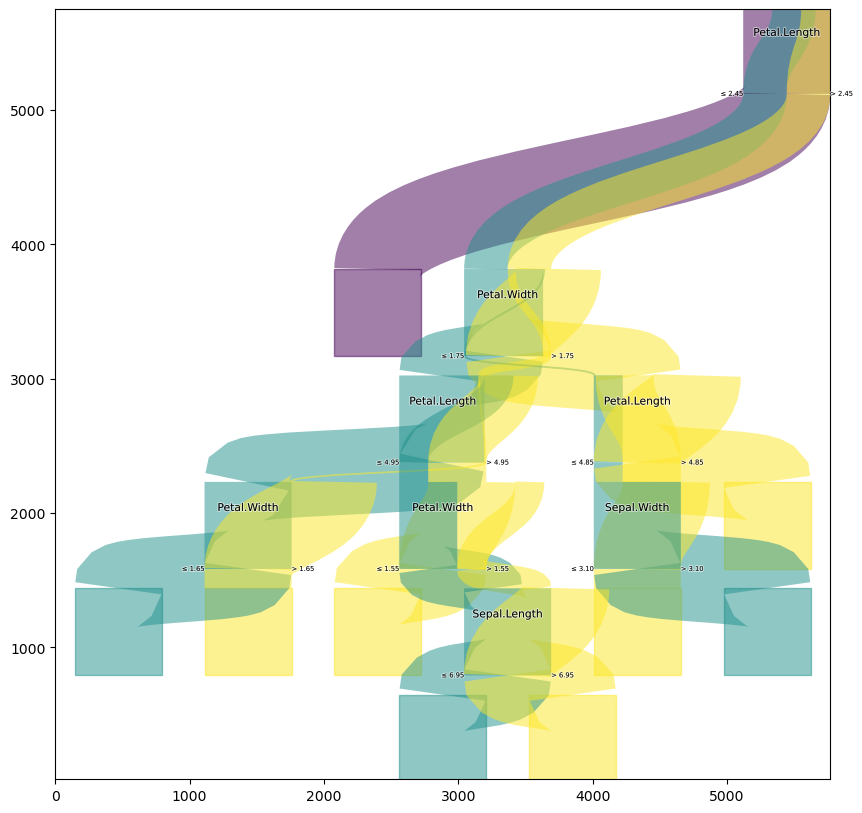

In [8]:
df = data
y = list(df['Species'])
X = df.drop(columns=['Species'])
features = list(X.columns)
clf = DecisionTreeClassifier().fit(X,y)
ax = pybaobabdt.drawTree(clf, size=10, dpi=300, features=features)  #Visualize the tree

通过使用颜色图，我们还可以突出显示特定的类别：

TypeError: decoding str is not supported

<Figure size 6000x6000 with 0 Axes>

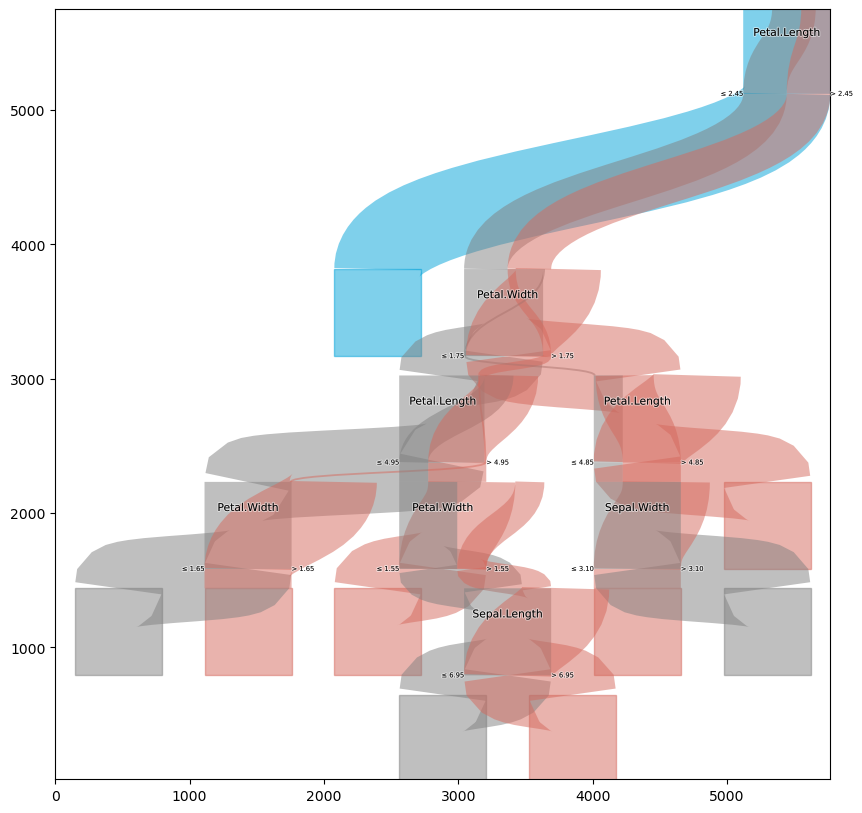

In [9]:
from matplotlib.colors import ListedColormap


ax = pybaobabdt.drawTree(
    clf,
    size=10,
    dpi=600,
    maxdepth=6,
    colormap=ListedColormap(["#01a2d9", "gray", "#d5695d",
                                "gray"]),  # Highlight Class 3 and 5
    features=features)

# 随机森林可视化

TypeError: decoding str is not supported

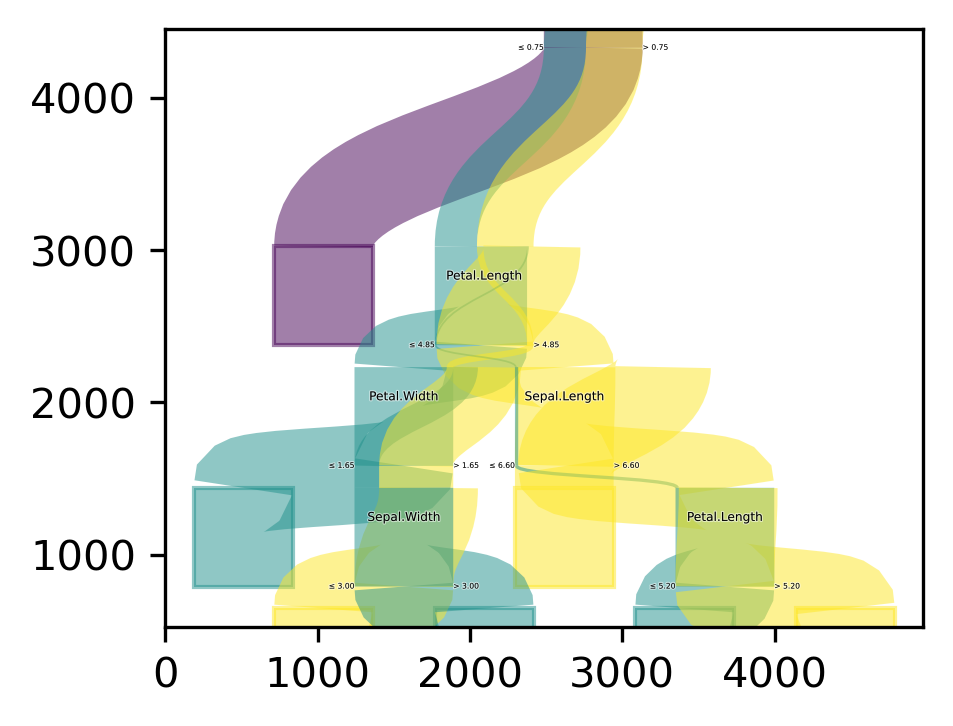

In [10]:
import pybaobabdt
import pandas as pd
from scipy.io import arff
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier

y = list(df['Species'])

X = df.drop(columns=['Species'])
features = list(X.columns)

clf = RandomForestClassifier(n_estimators=20, n_jobs=-1, random_state=0)
clf.fit(X,y)

size = (15,15)
plt.rcParams['figure.figsize'] = size
fig = plt.figure(figsize=size, dpi=300)


for idx, tree in enumerate(clf.estimators_):
    ax1 = fig.add_subplot(5, 4, idx + 1)

    pybaobabdt.drawTree(tree,
                    model=clf,
                    size=15,
                    dpi=300,
                    maxdepth=8,  # Set the depth for each tree
                    features=features,
                    ax=ax1)

参考资料：https://mp.weixin.qq.com/s/BdtQljnb63qN31gmawIRpA

